# NPSE on empirical WF data


In [1]:
from pathlib import Path
import os
import pickle
import sys
import warnings
from packaging.version import Version

LOCAL_CACHE_DIR = Path('.cache').resolve()
MPL_CACHE_DIR = LOCAL_CACHE_DIR / 'matplotlib'
LOCAL_CACHE_DIR.mkdir(exist_ok=True)
MPL_CACHE_DIR.mkdir(exist_ok=True)
os.environ['XDG_CACHE_HOME'] = str(LOCAL_CACHE_DIR)
os.environ['MPLCONFIGDIR'] = str(MPL_CACHE_DIR)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
try:
    import seaborn as sns
except ModuleNotFoundError:
    sns = None

import torch
import sbi
from sbi.inference import NPSE
from sbi.utils import BoxUniform
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)
from tqdm.auto import tqdm

if Version(sbi.__version__) < Version('0.24'):
    raise RuntimeError(
        f'NPSE iid sampling requires sbi>=0.24; this kernel has sbi=={sbi.__version__}. '
        'Update the collective_rev environment from requirements.txt and restart the kernel.'
    )

sys.path.insert(1, '../')
from simulators import WF

warnings.simplefilter('ignore', Warning)
plt.rcParams['figure.dpi'] = 600

TESTS_DIR = Path('tests')
POSTERIORS_DIR = Path('posteriors')
TESTS_DIR.mkdir(exist_ok=True)
POSTERIORS_DIR.mkdir(exist_ok=True)

LINES = ['wt', 'ltr', 'ars', 'all']
PARAM_NAMES = ['s', 'delta', 'p0']
N_EMPIRICAL_SAMPLES = 10_000
N_CYCLE_REPS = 10
NUM_SIMS = 30_000
FORCE_TRAIN_NPSE = True
REUSE_EXISTING_SAMPLE_FILES = True
POSTERIOR_NPSE_PATH = POSTERIORS_DIR / 'posterior_npse.pkl'

generation = pd.read_csv('empirical_data/Chuong_116_gens.txt').columns.astype(int)

prior = BoxUniform(
    low=torch.tensor([-2, -7, -8], dtype=torch.float32),
    high=torch.tensor([0, -2, -2], dtype=torch.float32),
)
prior, num_parameters, prior_returns_numpy = process_prior(prior)
noisy_WF = lambda params: WF(params, noise=True)
simulator = process_simulator(noisy_WF, prior, prior_returns_numpy)
check_sbi_inputs(simulator, prior)

if hasattr(prior, 'base_dist') and hasattr(prior.base_dist, 'low'):
    prior_low = prior.base_dist.low.detach().cpu()
    prior_high = prior.base_dist.high.detach().cpu()
else:
    prior_low = prior.low.detach().cpu()
    prior_high = prior.high.detach().cpu()
prior_width = prior_high - prior_low


## Train or load NPSE


In [2]:
TRAINED_NPSE_THIS_RUN = FORCE_TRAIN_NPSE or not POSTERIOR_NPSE_PATH.exists()

if TRAINED_NPSE_THIS_RUN:
    theta_train = prior.sample((NUM_SIMS,))
    x_train = simulator(theta_train)

    inference = NPSE(prior)
    _ = inference.append_simulations(theta_train, x_train).train()
    posterior_npse = inference.build_posterior()

posterior_npse


 Neural network successfully converged after 692 epochs.

VectorFieldPosterior sampler for potential_fn=<VectorFieldBasedPotential>

## Empirical estimates and inference cycle


In [3]:
def load_empirical_wf(line):
    Xs = pd.read_csv(f'empirical_data/{line}.csv', index_col=0)
    return torch.tensor(np.array(Xs), dtype=torch.float32)


def maybe_load_samples(path, n_samples):
    if TRAINED_NPSE_THIS_RUN or not REUSE_EXISTING_SAMPLE_FILES or not path.exists():
        return None
    samples = torch.load(path)
    if isinstance(samples, torch.Tensor) and samples.shape[0] == n_samples:
        return samples.detach().cpu()
    return None


def sample_npse_for_x(Xs, n_samples, output_path=None):
    if output_path is not None:
        samples = maybe_load_samples(output_path, n_samples)
        if samples is not None:
            return samples

    posterior_x = posterior_npse.set_default_x(Xs.to(torch.float32))
    try:
        samples = posterior_x.sample((n_samples,))
    except TypeError as err:
        if 'iid_method' not in str(err):
            raise
        raise RuntimeError(
            'This notebook requires sbi>=0.24 for NPSE iid sampling. '
            'Update collective_rev from requirements.txt and restart the kernel.'
        ) from err

    samples = samples.detach().cpu()
    if output_path is not None:
        torch.save(samples, output_path)
    return samples


def simulate_cycle_observations(theta_mean, n_reps=N_CYCLE_REPS):
    theta_mean = theta_mean.detach().cpu()
    return torch.stack([WF(parameters=theta_mean).to(torch.float32) for _ in range(n_reps)])


def add_sample_stats(row, samples, prefix):
    mean = samples.mean(0)
    std = samples.std(0)
    for idx, name in enumerate(PARAM_NAMES):
        row[f'{prefix}_mean_{name}'] = float(mean[idx])
        row[f'{prefix}_std_{name}'] = float(std[idx])
    return row


npse_empirical_samples = {}
npse_cycle_samples = {}
npse_cycle_observations = {}
summary_rows = []
cycle_rows = []

for line in tqdm(LINES, desc='NPSE empirical estimates + inference cycle'):
    Xs = load_empirical_wf(line)
    empirical_path = TESTS_DIR / f'samples_npse_{line}.pt'
    cycle_path = TESTS_DIR / f'cycle_samples_npse_{line}.pt'
    cycle_x_path = TESTS_DIR / f'cycle_observations_npse_{line}.pt'

    empirical_samples = sample_npse_for_x(Xs, N_EMPIRICAL_SAMPLES, empirical_path)
    empirical_mean = empirical_samples.mean(0)

    x_cycle = simulate_cycle_observations(empirical_mean, N_CYCLE_REPS)
    cycle_samples = sample_npse_for_x(x_cycle, N_EMPIRICAL_SAMPLES, cycle_path)
    cycle_mean = cycle_samples.mean(0)

    torch.save(x_cycle.detach().cpu(), cycle_x_path)

    npse_empirical_samples[line] = empirical_samples
    npse_cycle_samples[line] = cycle_samples
    npse_cycle_observations[line] = x_cycle.detach().cpu()

    summary_row = {'line': line, 'n_observed_reps': int(Xs.shape[0]), 'n_samples': N_EMPIRICAL_SAMPLES}
    add_sample_stats(summary_row, empirical_samples, 'empirical')
    summary_rows.append(summary_row)

    cycle_row = {
        'line': line,
        'n_cycle_reps': N_CYCLE_REPS,
        'n_samples': N_EMPIRICAL_SAMPLES,
        'nmae_means': float(((cycle_mean - empirical_mean).abs() / prior_width).mean()),
    }
    add_sample_stats(cycle_row, empirical_samples, 'empirical')
    add_sample_stats(cycle_row, cycle_samples, 'cycle')
    for idx, name in enumerate(PARAM_NAMES):
        cycle_row[f'mean_shift_{name}'] = float((cycle_mean[idx] - empirical_mean[idx]).abs())
    cycle_rows.append(cycle_row)


torch.save(npse_empirical_samples, TESTS_DIR / 'samples_npse_empirical.pt')
torch.save(npse_cycle_samples, TESTS_DIR / 'cycle_samples_npse_empirical.pt')
torch.save(npse_cycle_observations, TESTS_DIR / 'cycle_observations_npse_empirical.pt')

npse_summary_df = pd.DataFrame(summary_rows)
npse_cycle_df = pd.DataFrame(cycle_rows)
npse_summary_df.to_csv(TESTS_DIR / 'npse_empirical_summary.csv', index=False)
npse_cycle_df.to_csv(TESTS_DIR / 'npse_inference_cycle_summary.csv', index=False)

display(npse_summary_df)
display(npse_cycle_df)


NPSE empirical estimates + inference cycle:   0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

Generating 10000 posterior samples in 499 diffusion steps.:   0%|          | 0/499 [00:00<?, ?it/s]

Generating 100 posterior samples in 499 diffusion steps.:   0%|          | 0/499 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

...

  0%|          | 0/10000 [00:00<?, ?it/s]

Generating 10000 posterior samples in 499 diffusion steps.:   0%|          | 0/499 [00:00<?, ?it/s]

Generating 177 posterior samples in 499 diffusion steps.:   0%|          | 0/499 [00:00<?, ?it/s]

,line,n_observed_reps,n_samples,empirical_mean_s,empirical_std_s,empirical_mean_delta,empirical_std_delta,empirical_mean_p0,empirical_std_p0
0,wt,5,10000,-0.703549,0.020811,-4.743391,0.143938,-4.236469,0.160858
1,ltr,7,10000,-0.684570,0.022820,-5.118544,0.182080,-4.624309,0.210817
2,ars,7,10000,-0.795504,0.014695,-5.801318,0.138071,-5.619353,0.166967
3,all,8,10000,-0.887694,0.012678,-4.912336,0.094901,-5.063733,0.106382


,line,n_cycle_reps,n_samples,nmae_means,empirical_mean_s,empirical_std_s,empirical_mean_delta,empirical_std_delta,empirical_mean_p0,empirical_std_p0,cycle_mean_s,cycle_std_s,cycle_mean_delta,cycle_std_delta,cycle_mean_p0,cycle_std_p0,mean_shift_s,mean_shift_delta,mean_shift_p0
0,wt,10,10000,0.010505,-0.703549,0.020811,-4.743391,0.143938,-4.236469,0.160858,-0.711732,0.018986,-4.679722,0.135560,-4.148324,0.154709,0.008183,0.063669,0.088144
1,ltr,10,10000,0.007532,-0.684570,0.022820,-5.118544,0.182080,-4.624309,0.210817,-0.689296,0.023384,-5.081043,0.191912,-4.547906,0.217493,0.004726,0.037501,0.076403
2,ars,10,10000,0.022354,-0.795504,0.014695,-5.801318,0.138071,-5.619353,0.166967,-0.787104,0.012946,-5.905016,0.135599,-5.872084,0.160543,0.008401,0.103698,0.252731
3,all,10,10000,0.001664,-0.887694,0.012678,-4.912336,0.094901,-5.063733,0.106382,-0.889314,0.012833,-4.910100,0.097246,-5.086143,0.126229,0.001620,0.002236,0.022411


## Load saved samples


In [4]:
npse_empirical_samples = torch.load(TESTS_DIR / 'samples_npse_empirical.pt')
npse_cycle_samples = torch.load(TESTS_DIR / 'cycle_samples_npse_empirical.pt')
npse_cycle_observations = torch.load(TESTS_DIR / 'cycle_observations_npse_empirical.pt')
npse_summary_df = pd.read_csv(TESTS_DIR / 'npse_empirical_summary.csv')
npse_cycle_df = pd.read_csv(TESTS_DIR / 'npse_inference_cycle_summary.csv')

npse_summary_df, npse_cycle_df


(  line  n_observed_reps  n_samples  empirical_mean_s  empirical_std_s  \
 0   wt                5      10000         -0.703549         0.020811   
 1  ltr                7      10000         -0.684570         0.022820   
 2  ars                7      10000         -0.795504         0.014695   
 3  all                8      10000         -0.887694         0.012678   
 
    empirical_mean_delta  empirical_std_delta  empirical_mean_p0  \
 0             -4.743391             0.143938          -4.236469   
 1             -5.118544             0.182080          -4.624309   
 2             -5.801318             0.138071          -5.619353   
 3             -4.912336             0.094901          -5.063733   
 
    empirical_std_p0  
 0          0.160858  
 1          0.210817  
 2          0.166967  
 3          0.106382  ,
   line  n_cycle_reps  n_samples  nmae_means  empirical_mean_s  \
 0   wt            10      10000    0.010505         -0.703549   
 1  ltr            10      10000    0.

## NPSE inference-cycle KDE check


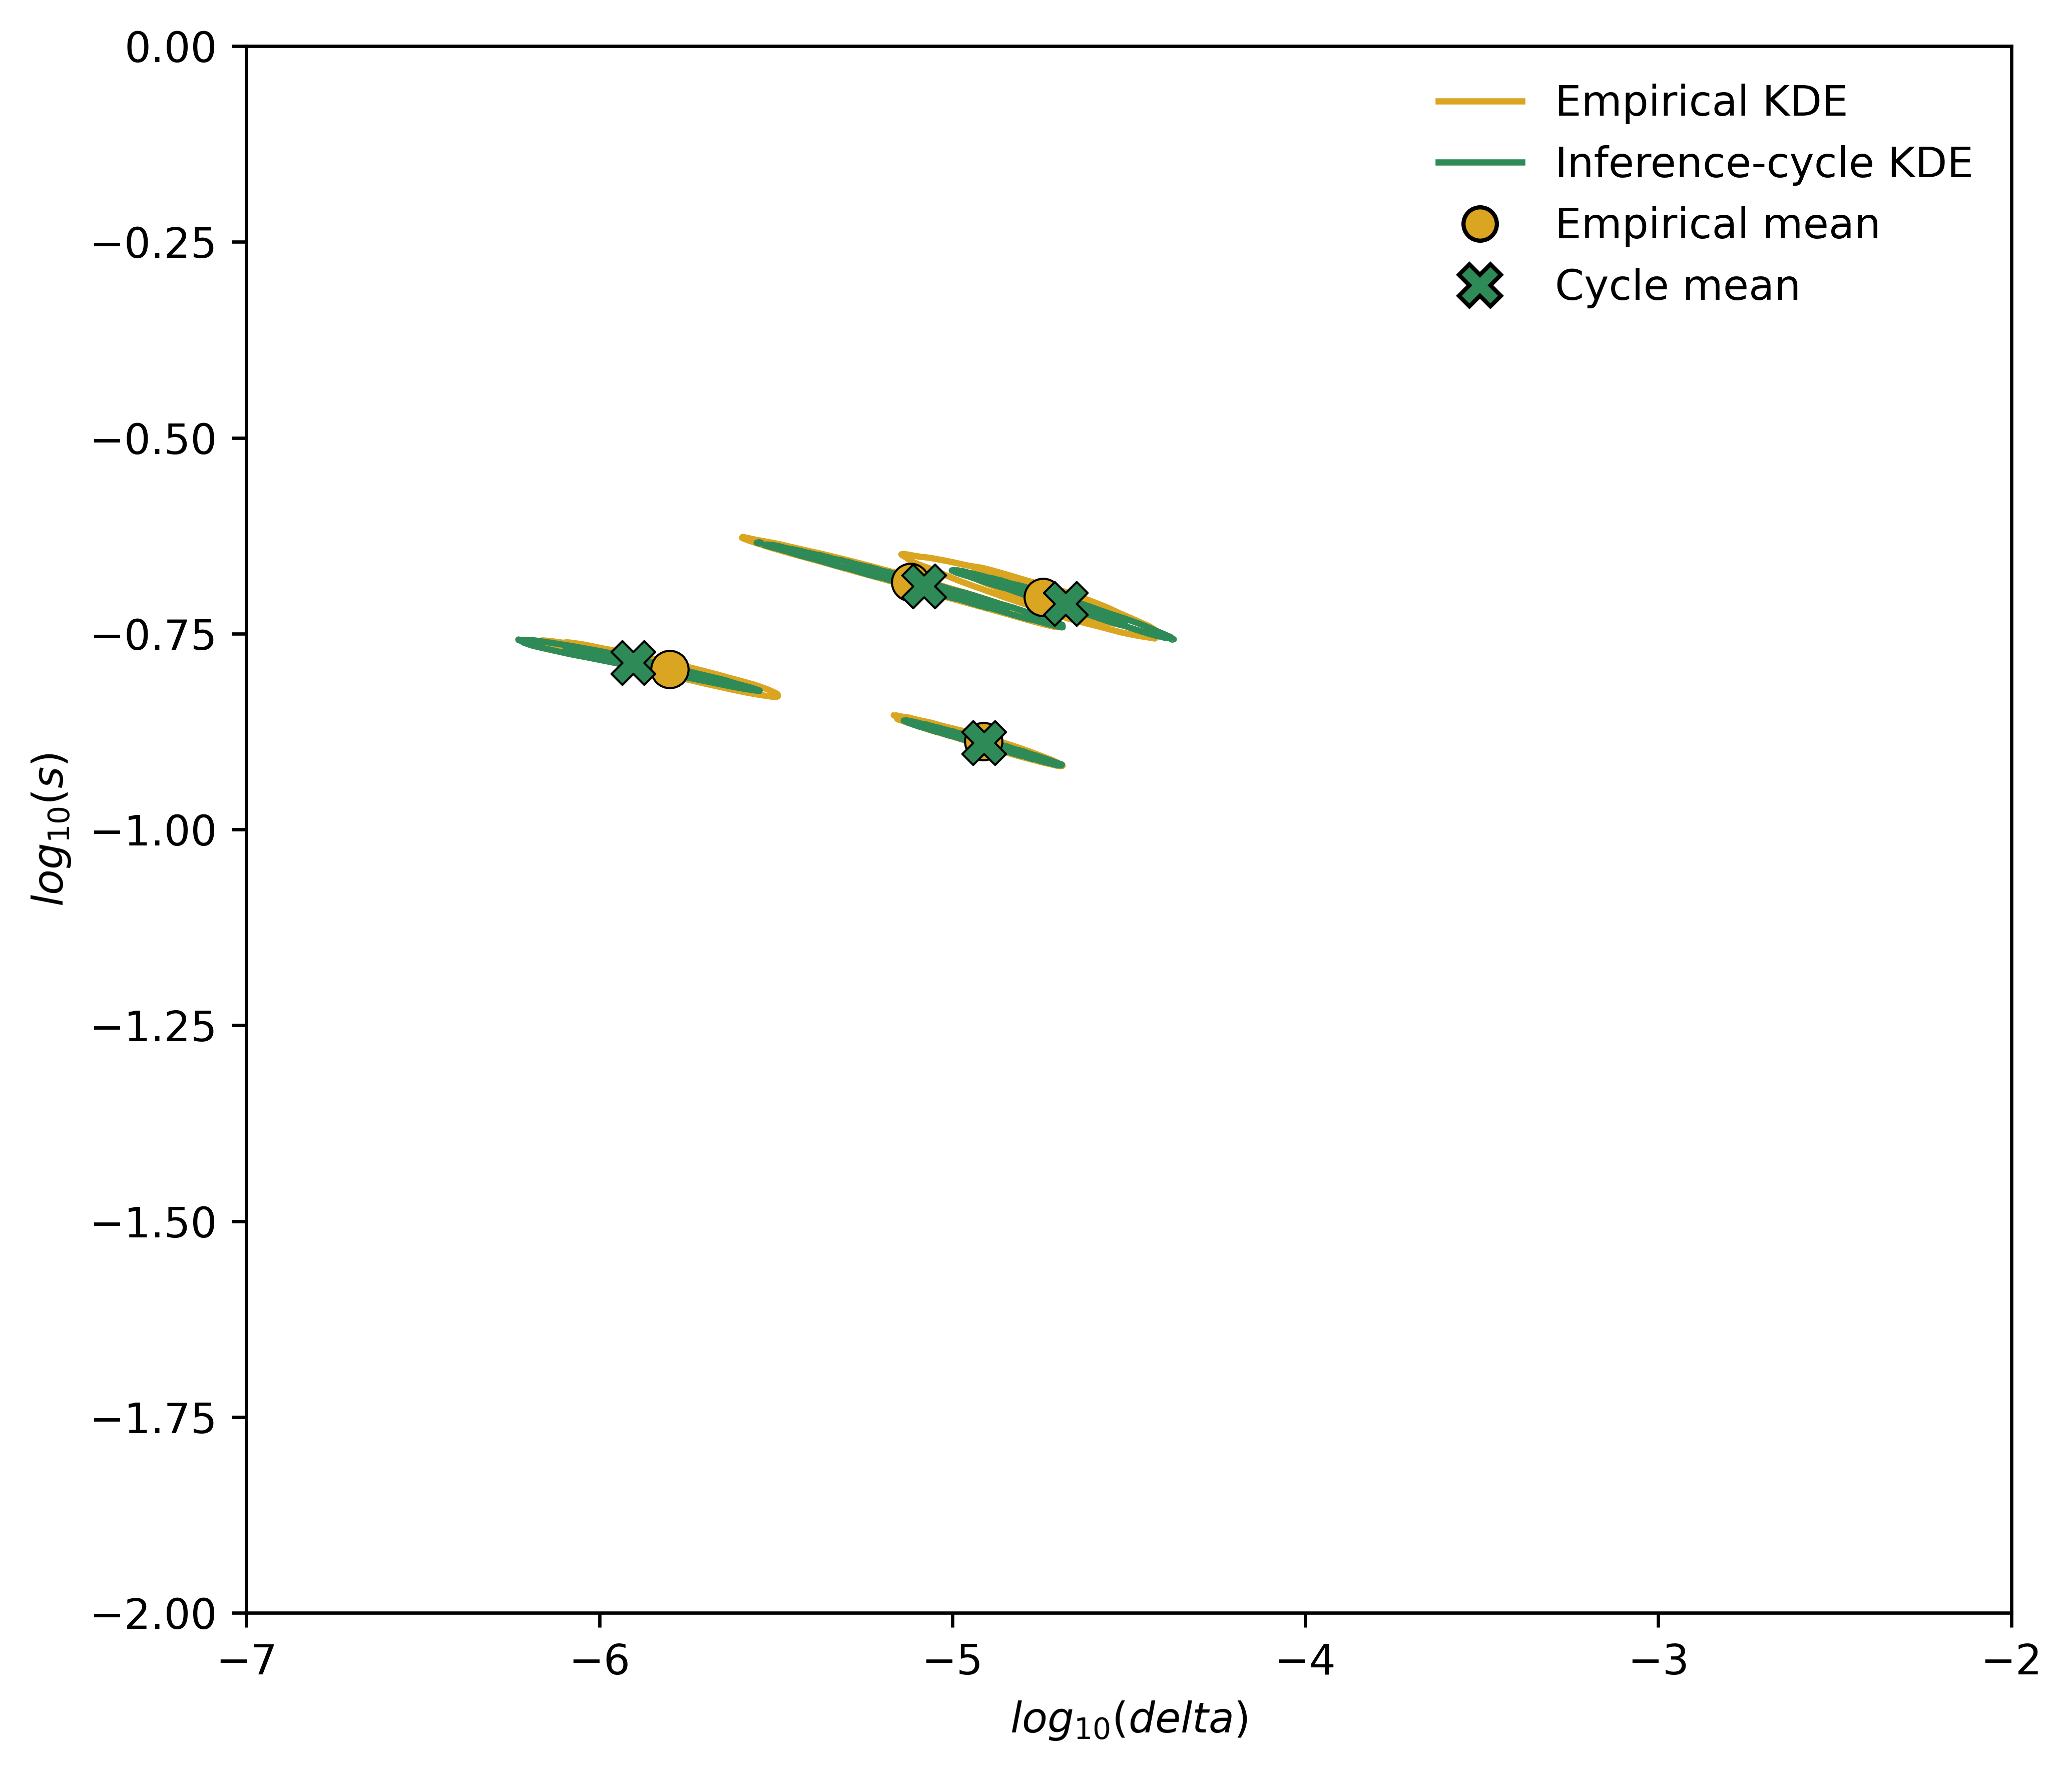

,line,n_cycle_reps,n_samples,nmae_means,empirical_mean_s,empirical_std_s,empirical_mean_delta,empirical_std_delta,empirical_mean_p0,empirical_std_p0,cycle_mean_s,cycle_std_s,cycle_mean_delta,cycle_std_delta,cycle_mean_p0,cycle_std_p0,mean_shift_s,mean_shift_delta,mean_shift_p0
0,wt,10,10000,0.010505,-0.703549,0.020811,-4.743391,0.143938,-4.236469,0.160858,-0.711732,0.018986,-4.679722,0.135560,-4.148324,0.154709,0.008183,0.063669,0.088144
1,ltr,10,10000,0.007532,-0.684570,0.022820,-5.118544,0.182080,-4.624309,0.210817,-0.689296,0.023384,-5.081043,0.191912,-4.547906,0.217493,0.004726,0.037501,0.076403
2,ars,10,10000,0.022354,-0.795504,0.014695,-5.801318,0.138071,-5.619353,0.166967,-0.787104,0.012946,-5.905016,0.135599,-5.872084,0.160543,0.008401,0.103698,0.252731
3,all,10,10000,0.001664,-0.887694,0.012678,-4.912336,0.094901,-5.063733,0.106382,-0.889314,0.012833,-4.910100,0.097246,-5.086143,0.126229,0.001620,0.002236,0.022411


In [5]:
if sns is None:
    raise ModuleNotFoundError(
        "seaborn is required only for this KDE plot. Install it with: "
        "conda run -n collective_rev python -m pip install seaborn==0.13.2"
    )

fig, ax = plt.subplots(1, 1, figsize=(7, 6), tight_layout=True)
original_color = 'goldenrod'
cycle_color = 'seagreen'

for line in LINES:
    empirical_samples = npse_empirical_samples[line]
    cycle_samples = npse_cycle_samples[line]
    sns.kdeplot(
        x=empirical_samples[:, 1],
        y=empirical_samples[:, 0],
        color=original_color,
        lw=1.0,
        levels=5,
        ax=ax,
        label='Empirical NPSE' if line == LINES[0] else None,
    )
    sns.kdeplot(
        x=cycle_samples[:, 1],
        y=cycle_samples[:, 0],
        color=cycle_color,
        lw=1.0,
        levels=5,
        ax=ax,
        label='Inference-cycle NPSE' if line == LINES[0] else None,
    )

for line in LINES:
    empirical_mean = npse_empirical_samples[line].mean(0)
    cycle_mean = npse_cycle_samples[line].mean(0)
    ax.scatter(float(empirical_mean[1]), float(empirical_mean[0]), color=original_color, s=80, marker='o', edgecolor='black', linewidth=0.5, zorder=10)
    ax.scatter(float(cycle_mean[1]), float(cycle_mean[0]), color=cycle_color, s=110, marker='X', edgecolor='black', linewidth=0.5, zorder=11)

handles = [
    plt.Line2D([0], [0], color=original_color, lw=1.5, label='Empirical KDE'),
    plt.Line2D([0], [0], color=cycle_color, lw=1.5, label='Inference-cycle KDE'),
    plt.Line2D([0], [0], marker='o', color=original_color, markeredgecolor='black', linestyle='None', markersize=8, label='Empirical mean'),
    plt.Line2D([0], [0], marker='X', color=cycle_color, markeredgecolor='black', linestyle='None', markersize=10, label='Cycle mean'),
]
ax.legend(handles=handles, frameon=False, loc='best')
ax.set_xlim(float(prior_low[1]), float(prior_high[1]))
ax.set_ylim(float(prior_low[0]), float(prior_high[0]))
ax.set_xlabel('$log_{10}(delta)$')
ax.set_ylabel('$log_{10}(s)$')
plt.show()

display(npse_cycle_df)


## NPSE posterior predictive check


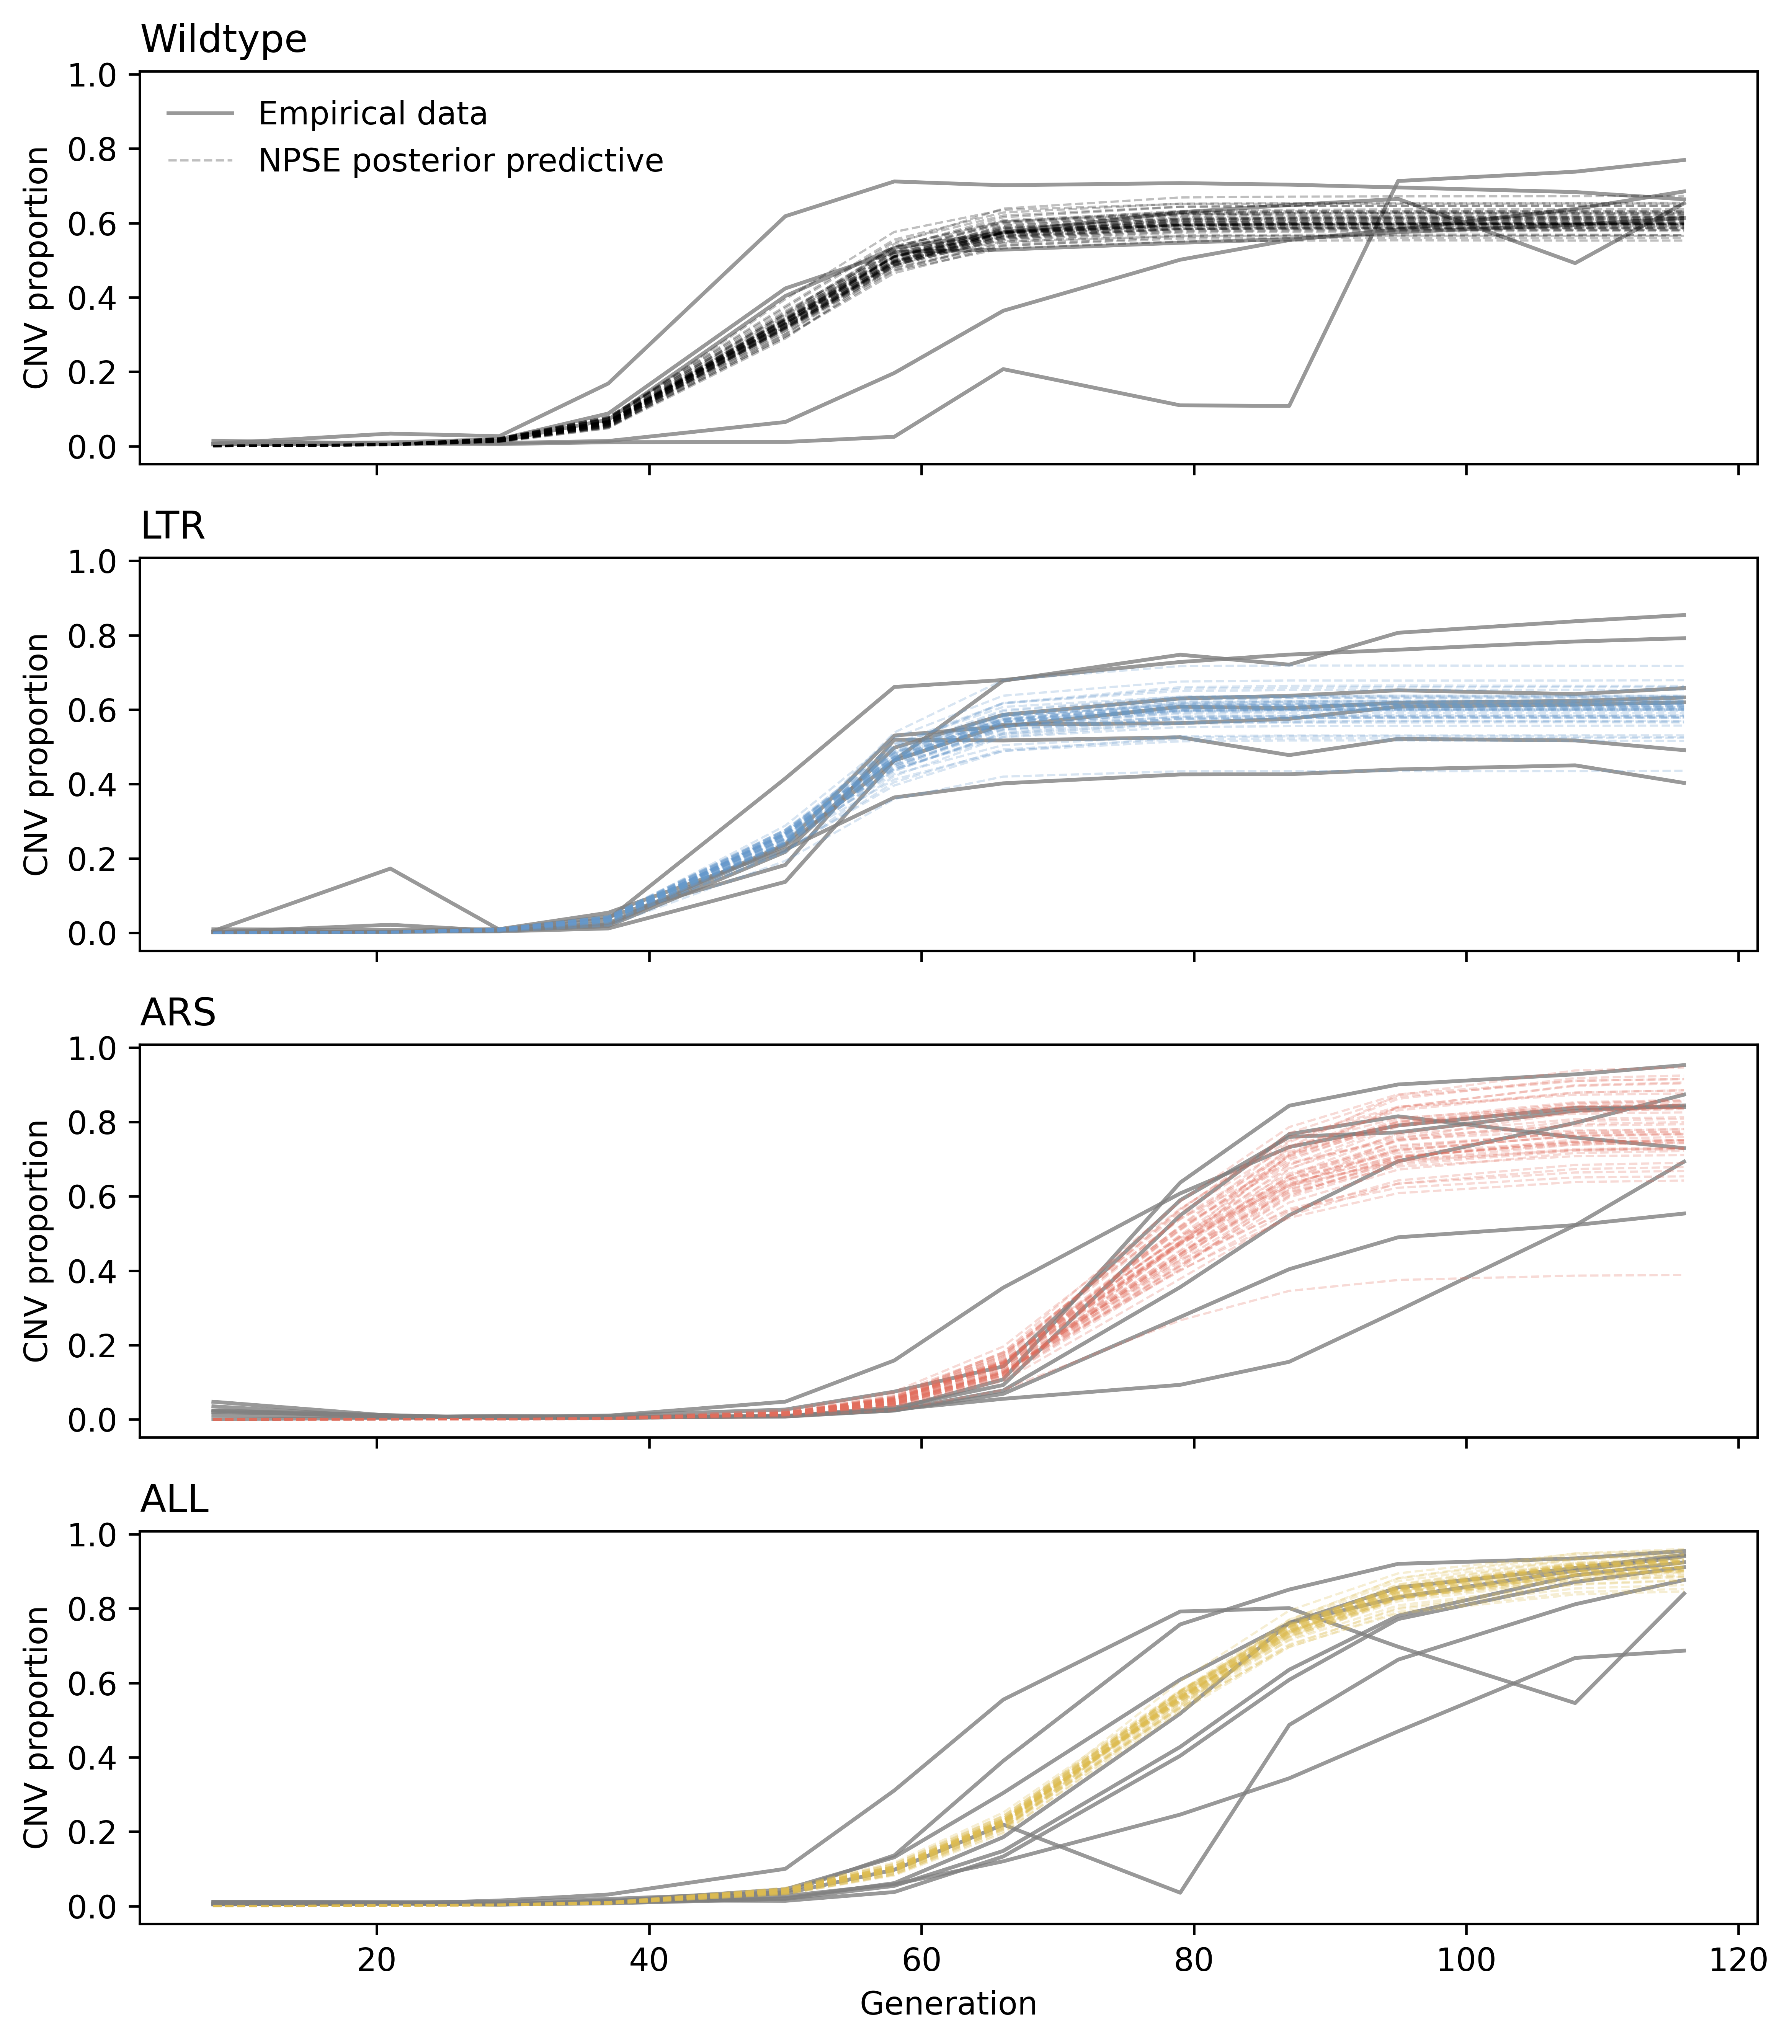

In [6]:
fig, axes = plt.subplots(len(LINES), 1, figsize=(8, 9), sharex=True, sharey=True, tight_layout=True)
rep_colors = {'wt': 'black', 'ltr': '#6699cc', 'ars': '#e26d5c', 'all': '#DEBD52'}
label_dict = {'wt': 'Wildtype', 'ltr': 'LTR', 'ars': 'ARS', 'all': 'ALL'}

for ax, line in zip(axes, LINES):
    Xs = load_empirical_wf(line)
    samples = npse_empirical_samples[line]
    preview_samples = samples[:50]

    for i, x in enumerate(Xs):
        ax.plot(generation, x, color='grey', lw=1.2, alpha=0.8, label='Empirical data' if i == 0 else None)

    for j, theta in enumerate(preview_samples):
        ax.plot(
            generation,
            WF(parameters=theta).cpu(),
            color=rep_colors[line],
            ls='--',
            lw=0.7,
            alpha=0.25,
            label='NPSE posterior predictive' if j == 0 else None,
        )

    ax.set_title(label_dict[line], loc='left')
    ax.set_ylabel('CNV proportion')

axes[-1].set_xlabel('Generation')
axes[0].legend(frameon=False, loc='best')
plt.show()
